<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/06_3_%EA%B7%B8%EB%A6%AC%EB%93%9C_%EC%84%9C%EC%B9%98%EC%97%90_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EC%A0%81%EC%9A%A9%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


- 파이프라인용 매개변수 그리드는 단계 이름과 매개변수 이름을 `__`로 연결해 만듦

In [4]:
# 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)


In [1]:
param_grid = {"svm__C": [0.001, 0.01, 0.1, 1, 10, 100],
              "svm__gamma": [0.001, 0.01, 0.1, 1, 10, 100]}

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

pipe = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC())])

In [6]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"최상의 교차 검증 정확도: {round(grid.best_score_, 2)}")
print(f"테스트 세트 점수: {round(grid.score(X_test, y_test), 2)}")
print(f"최적의 매개변수: {grid.best_params_}")

최상의 교차 검증 정확도: 0.98
테스트 세트 점수: 0.97
최적의 매개변수: {'svm__C': 1, 'svm__gamma': 1}


- 교차 검증의 각 분할에 `MinMaxScaler`가 훈련 폴드에 매번 적용되어, 매개변수 검색 과정에서 검증 폴드의 정보가 누설되지 않음

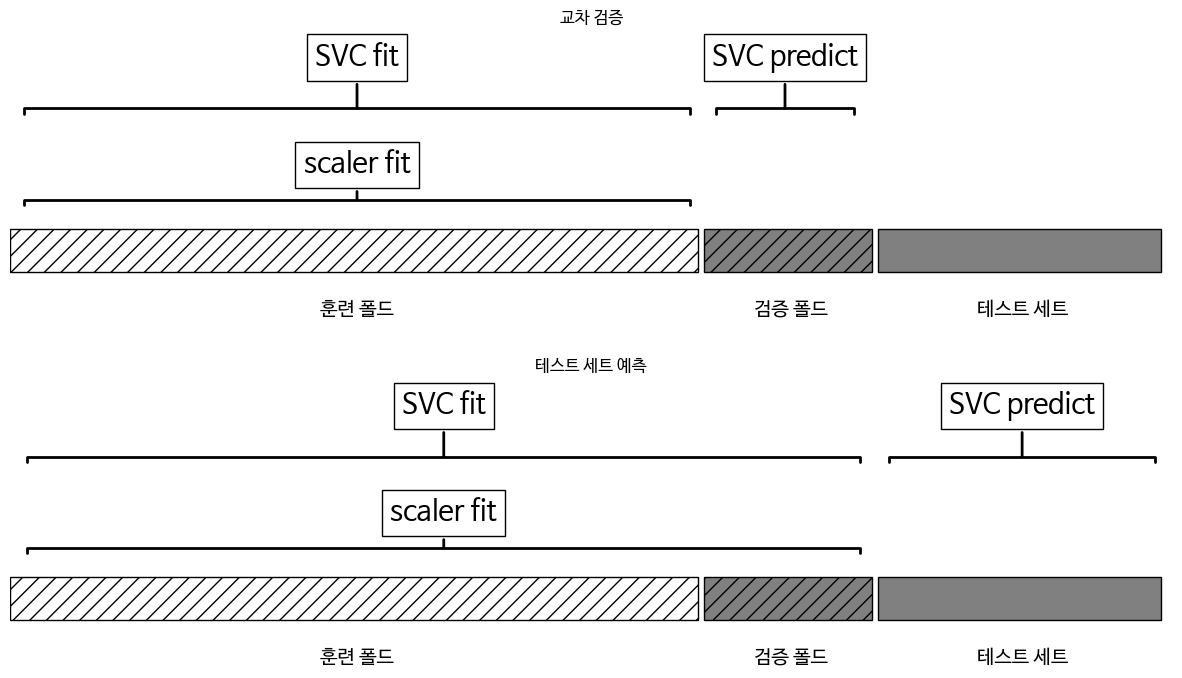

In [7]:
# 교차 검증 반복 안에서 전처리가 될 때 데이터 사용 형태
mglearn.plots.plot_proper_processing()

- 교차 검증에서 정보 누설에 의한 영향은 전처리 종류에 따라 다름
- 검증 폴드를 사용해 데이터의 스케일을 조정하는 경우엔 심각한 문제가 생기지 않지만, 검증 폴드를 이용해 특성을 추출하거나 선택하면 결과가 확연히 달라짐

## 정보 누설에 대한 예시

In [8]:
# 데이터 로드: 독립적으로 추출한 10000개의 특성을 가진 샘플 100개를 사용한 회귀 문제
# 독립적으로 추출하였으므로 X, y 사이에는 아무런 관계가 없음

rnd = np.random.RandomState(seed=0)
X = rnd.normal(size=(100, 10000))
y = rnd.normal(size=(100,))

In [9]:
# SelectPercentile로 유용한 특성을 선택
from sklearn.feature_selection import SelectPercentile, f_regression

select = SelectPercentile(score_func=f_regression, percentile=5).fit(X, y)
X_selected = select.transform(X)
print(f"X_selected.shape: {X_selected.shape}")

X_selected.shape: (100, 500)


In [11]:
# 교차 검증을 사용하여 Ridge 회귀
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

print(f"교차 검증 점수(Ridge): {round(np.mean(cross_val_score(Ridge(), X_selected, y, cv=5)), 2)}")

교차 검증 점수(Ridge): 0.91


- 독립적인 데이터셋이므로 $R^2$가 0.91로 높게 나온 것은 불가능함
- 👉 테스트 폴드에서 정보 유출: 교차 검증 밖에서 특성을 선택했기 때문에 훈련과 테스트 폴드 양쪽에 연관된 특성이 찾아질 수 있음

In [14]:
pipe = Pipeline([("select", SelectPercentile(score_func=f_regression,
                                             percentile=5)),
                 ("ridge", Ridge())])
print(f"교차 검증 점수(파이프라인): {round(np.mean(cross_val_score(pipe, X, y, cv=5), ), 2)}")

교차 검증 점수(파이프라인): -0.25


- 파이프라인을 사용하여 특성 선택이 교차 검증 반복 안으로 들어감
- 👉 훈련 폴드를 사용해서만 특성이 선택되었고 테스트 폴드는 사용하지 않음